# MiniLab 5: Census Data in Python

## Learning Objectives:
* Define U.S. Census and ACS data sources
* Compare decennial census with ACS estimates and identify strengths and limitations
* Identify spatial extent of census data
* Discuss similarities and differences between federal data schemas
* Outline and apply tools that enable access and application of Census Data

---

## **1. Why Geography Matters**

- Geography shapes how the U.S. Census Bureau samples and aggregates data.
- **Geography ≠ visualization only**: it's embedded in data collection, sampling units, and margin-of-error computation.
- Example of misunderstanding: comparing population estimates without aligning geographic levels.

### Geographic Hierarchy of the U.S. Census

- Geographic areas are organized in a geographic hierarchy.

- Larger units, like states, include smaller units, like counties and census tracts.

- This structure is derived from the legal, administrative, or areal relationships of the entities.

<img src="https://www.census.gov/programs-surveys/acs/geography-acs/concepts-definitions/_jcr_content/root/responsivegrid/expcolaccordioncore209/section_1/imagecore.coreimg.jpeg/1678878894635/acs-geographic-hierarchy.jpeg" style="height:500px" />

<p>Image source: Census.org</p>

<!-- - Nation → State → County → Place (City) → [Zip Code Tabulation Area (ZCTA)](https://www.census.gov/programs-surveys/geography/guidance/geo-areas/zctas.html) → Tract → Block Group -->
- Tracts: ~4,000 people; Block Groups: ~1,500
- **Note**: ACS does not publish at the *block* level.
- Explore glossary: [Census Glossary](https://www.census.gov/programs-surveys/geography/about/glossary.html)


### FIPS Codes (Federal Information Processing Series)

The Census Bureau has used **FIPS codes** for over 30 years. These are standardized numeric codes used to identify political and statistical areas such as:

* States
* Counties
* Cities and towns
* Native American areas
---


## ❗️ Try it Out ❗️
FIPS codes are usually **assigned alphabetically** within each level of geography. Importantly, they’re **nested**—for example:

* Texas has a state FIPS code of `48`
* Harris County within Texas has a county FIPS of `201`
* So Harris County's full FIPS code is `48201`

This nesting ensures each code is **unique nationwide**.

## 1.1. - Navigate to Census Geocoder Tool
Navigate to the following link:  [https://geocoding.geo.census.gov/geocoder/geographies/onelineaddress?form](https://geocoding.geo.census.gov/geocoder/geographies/onelineaddress?form)

## 1.2. - Type in an address
Retain default values for benchmark and vintage.

## 1.3. - Enter in the GEOID and the expected FIPS code for the **TRACT** in the code cell below
Populate the empty fields with comments in the code cell below, then run it.


In [1]:
# Based on the tabular data returned for the address you inputted, what is
# the expected FIPS Code for the tract?
state_code = '06'      # California
county_code = '001'    # Alameda County
tract_code = '422902'  # Census Tract 4229.02

# The GEOID is the complete FIPS code (concatenation of state + county + tract)
fips_code = state_code + county_code + tract_code

# Printing your FIPS Code
print(f"FIPS Code Breakdown:")
print(f"  State Code (2 digits): {state_code}")
print(f"  County Code (3 digits): {county_code}")
print(f"  Tract Code (6 digits): {tract_code}")
print(f"  Complete FIPS Code (11 digits): {fips_code}")

# B. Based on the tabular data returned for the address you inputted, what GEOID is associated with the address?
my_GEOID = '06001422902'  # From the Census Tracts GEOID field

print(f"The GEOID for my inputted address is: {my_GEOID}")

FIPS Code Breakdown:
  State Code (2 digits): 06
  County Code (3 digits): 001
  Tract Code (6 digits): 422902
  Complete FIPS Code (11 digits): 06001422902
The GEOID for my inputted address is: 06001422902


---
### Recap on GEOIDs


To work with U.S. Census and survey data, we need a way to *consistently identify places*. That’s where **GEOIDs** (Geographic Identifiers) come in.

GEOIDs are numeric codes that uniquely identify all administrative/legal and statistical geographic areas for which the Census Bureau tabulates data.

They are unique codes used to link demographic data to specific locations like states, counties, cities, or even blocks.

These codes are maintained by different organizations, including:

* The **U.S. Census Bureau**
* The **American National Standards Institute (ANSI)**
* The **U.S. Geological Survey (USGS)**
* The **Department of Education**
* Individual **state governments**


From Alaska, the largest state, to the smallest census block in New York City, every geographic area has a unique GEOID.

Data users rely on GEOIDs to accurately **join** demographic data from sources like the American Community Survey (ACS) to different geographic areas for analysis, interpretation, and mapping. Without a shared identifier between geographic and demographic datasets, it becomes much harder to match the right data to the right place, slowing down analysis and increasing the risk of errors.

> #### Tip: GEOIDs ≠ Geoid
> There is a concept in GIS called **geoid**, for calculating surface elevation. [NOAA - Geoid](https://oceanservice.noaa.gov/facts/geoid.html). This has nothing to do with our GEOIDs!

### Putting It Together: How GEOIDs Are Built

GEOIDs often combine multiple codes to represent geographic nesting. For example:


| Area Type          | GEOID Structure                | Example (Alameda County, CA) |
| ------------------ | ------------------------------ | ---------------------------- |
| State              | STATE (2 digits)               | `06`                         |
| County             | STATE + COUNTY (2+3)           | `06001`                      |
| Census Tract       | STATE + COUNTY + TRACT (2+3+6) | `06001400100`                |
| Census Block Group | STATE + COUNTY + TRACT + BG    | `060014001001`               |

**Breakdown**:

* `06` = California
* `001` = Alameda County
* `400100` = Census Tract 4001.00 (in, e.g., Oakland)
* `1` = Block Group 1 within that tract
<br>
This hierarchical structure enables precise geographic targeting and seamless joining of tabular data with spatial data in GIS or data analysis tools.

---

##❗️ Try it Out ❗️
Here you will try downloading data from [data.census.gov](https://data.census.gov) and finding the GEOID in downloaded census data.

## 1.4. - Begin by searching for a geography using the basic search tool


## 1.5. - Locate a table of your choosing
For example, you might look for the American Community Survey (ACS) Demographic and Housing Estimates (1-year) for census tracts in Alameda County in 2023--thats table DP05 for reference.

## 1.6. - Download the corresponding data as a `.zip` with GEOIDS and use the code cell below to load it in using pandas.
Remember you need to upload the csv data file into Colab to do this.  The "Geography" column corresponds to the **GEOID**.


In [4]:
import pandas as pd

# Read CSV file and skip the second row (contains variable descriptions)
my_census_export = pd.read_csv('ACSDP5Y2023.DP05-2026-07-05T194243.csv', skiprows=[0])

# Display the first 5 rows
my_census_export.head()

,SEX AND AGE,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 967,Unnamed: 968,Unnamed: 969,Unnamed: 970,Unnamed: 971,Unnamed: 972,Unnamed: 973,Unnamed: 974,Unnamed: 975,Unnamed: 976
0,Total population,"2,004",±297,"2,004",(X),"1,795",±345,"1,795",(X),"2,608",...,322,(X),0,±14,0,(X),0,±14,0,(X)
1,Male,"1,077",±173,53.7%,±5.1,786,±172,43.8%,±8.5,"1,325",...,57.1%,±15.5,0,±14,-,**,0,±14,-,**
2,Female,927,±187,46.3%,±5.1,"1,009",±285,56.2%,±8.5,"1,283",...,42.9%,±15.5,0,±14,-,**,0,±14,-,**
3,Sex ratio (males per 100 females),116.2,±23.6,(X),(X),77.9,±27.4,(X),(X),103.3,...,(X),(X),-,**,(X),(X),-,**,(X),(X)
4,Under 5 years,62,±64,3.1%,±3.0,45,±44,2.5%,±2.3,56,...,9.6%,±10.8,0,±14,-,**,0,±14,-,**


##❗️ Try it Out (Cont'd.)❗️
## 1.7. -  Break down those GEOIDs!
Use the code cell below to print a breakdown of one of your table's GEOIDs.  

You'll often see a column called `GEOID` in this case, the second header row denotes the GEOID as "Geography".  The first header row refers to it as GEOID. The GEOID column contains a long identifier like:

```
0500000US06001
```

This code breaks down as follows:

* `050` = Summary level (in this case, county)
* `0000` = Geographic variant and component (often all zeroes for standard geographies)
* `US` = United States
* `06` = California (state FIPS)
* `001` = Alameda County (county FIPS)

So `0500000US06001` uniquely identifies Alameda County, CA in census tabular data. This GEOID matches the one used in TIGER/Line shapefiles, enabling clean joins between spatial and demographic data.
>#### Tip: Why GEOIDs Matter
>* GEOIDs allow us to match data to geography **accurately** and **efficiently**.
>* They help avoid confusion when different datasets refer to the same places.
>* They're essential for mapping, analysis, and policy-making across many domains—planning, education, environment, health, and more.

In [5]:
# Specify the row index you want to analyze
row_index = 0  # You must change this to the row you want to examine

# Get the GEO_ID value (adjust column name if needed)
geoid = my_census_export['Geography'].iloc[row_index]

print(f"Full GEO_ID: {geoid}")
print(f"Breakdown:")
print(f"  Summary Level: {geoid[:3]}")       # census tract
print(f"  Geographic Variant: {geoid[3:7]}") # standard
print(f"  Country: {geoid[7:9]}")            # 'US'
print(f"  State FIPS: {geoid[9:11]}")        # California
print(f"  County FIPS: {geoid[11:14]}")      # Alameda County
print(f"  Tract Code: {geoid[14:]}")         # Census Tract 4011.00

KeyError: 'Geography'

> Tip: Does the result of this code conform to the standard described above?  Are there missing characters?  How might this be resolved?
---
## **2. ACS Products and Geography**

In this section we will load in census-related data using the census package.  We'll also introduce a few bonus tools.


> ### Understanding Vintages
> - Boundary changes happen every decade (or more frequently).
> - Use **Geocorr** to understand how 2010 vs 2020 tracts differ.
> - Always check which year a 5-year ACS product refers to (it's the *last* year).
> - Vintage example: 2021 ACS 5-year uses 2021 boundaries.
> - [Vintage FAQ](https://www.census.gov/programs-surveys/geography/technical-documentation/vintage.html)

---

## ❗️ Try it Out ❗️
In this section we'll load in some census data using the census package.

### 2.1. - Package Install

We begin by installing the required Python packages. You may run the following cell to install any packages not already available in your environment. Follow the instructions below to do this.

```
# Open the Terminal in the bottom lefthand corner of your screen.
# Run the following command by typing it in manually (case sensitive!)

pip install census
```

> **What is an API?**
API stands for Application Programming Interface. APIs deliver requests, retrieve the data, and return it in a structured format. APIs are commonly used across many platforms and services to automate data access and make complex systems easier to work with. For example, when you use a program like Python to access U.S. Census data, you're using an API to ask the Census Bureau's database for specific information—like the population of a county or the median household income.

---

### 2.2. - Retrieve and Store Census API Key

To access census data, you'll need a Census API key. You can request one from: [https://api.census.gov/data/key_signup.html](https://api.census.gov/data/key_signup.html)

* **Organization Name:** University of California, Berkeley
* **Email Address:** [YOUR BERKELEY EMAIL]
* Agree to TOC

Once you have your key, store it securely as an environment variable.  You can do this by clicking on the key icon in the toolbar to the left and adding a new secret with your API key called `censusAPIKey`.

### 2.3. - Load Required Libraries into Your Environment
In addition to the Census, pandas, and plotly libraries, you will also be importing the ```os``` library which helps your Python code talk to the system it is running on, even if you are using a virtual machine like you are doing right now in Colab.

In [15]:
from census import Census
import os
import pandas as pd
import plotly.express as px

from google.colab import userdata
censusAPIKey = Census(userdata.get('censusAPIKey'))

##❗️ Try it Out (Cont'd.)❗️
### 2.4. - Fetch ACS Tract Data

In this step, you will use the Census API to pull the **Aggregate Value (in Dollars) for Owner-Occupied Housing Units** (`B25082_001E`) for all census tracts in Alameda County, California, for both **2012** and **2023**. This data will be used in Section 3 when we apply the NHGIS crosswalk.

> **Curious about how to query the Census API?**
You can access the detailed documentation, including syntax guides and learning materials on the U.S. Census Bureau's website's [Developers](https://www.census.gov/data/developers.html) page.

Run the two code cells below to fetch the data for each year. The queries are pre-filled for you. Read through the inline comments carefully before running.

In [16]:
import numpy as np

STATE  = '06'    # California state FIPS code
COUNTY = '001'   # Alameda County FIPS code (Berkeley is located here)

# Query 1: 2012 ACS 5-year estimates (covering 2008-2012)
# These use 2010-vintage tract boundaries
raw2012 = censusAPIKey.acs5.state_county_tract(
    fields=('NAME', 'B25082_001E'),  # B25082_001E = Aggregate Home Value estimate
    state_fips=STATE,
    county_fips=COUNTY,
    tract='*',                       # '*' is a wildcard meaning "all tracts"
    year=2012                        # The year parameter is the LAST year of the 5-year period
)

# Convert the list of results into a pandas DataFrame
df2012 = pd.DataFrame(raw2012)

# Rename the variable column to something descriptive
df2012 = df2012.rename(columns={'B25082_001E': 'agg_value_2012'})

# Convert the value column to a number (it comes in as a string from the API)
df2012['agg_value_2012'] = pd.to_numeric(df2012['agg_value_2012'], errors='coerce')

# The Census API uses -666666666 to indicate suppressed or missing values
# Replace those with NaN so they are treated as missing in our analysis
df2012.loc[df2012['agg_value_2012'] < 0, 'agg_value_2012'] = np.nan

# Build a standard 11-digit tract GEOID by concatenating state + county + tract codes
df2012['trtid10'] = (
    df2012['state']    # 2-digit state FIPS
    + df2012['county'] # 3-digit county FIPS
    + df2012['tract']  # 6-digit tract code
)

print(df2012[['trtid10', 'NAME', 'agg_value_2012']].head())

       trtid10                                           NAME  agg_value_2012
0  06001402800  Census Tract 4028, Alameda County, California             NaN
1  06001404400  Census Tract 4044, Alameda County, California    1.598962e+09
2  06001400900  Census Tract 4009, Alameda County, California    1.712050e+08
3  06001402600  Census Tract 4026, Alameda County, California    2.943900e+07
4  06001404200  Census Tract 4042, Alameda County, California    1.026404e+09


In [17]:
# Query 2: 2023 ACS 5-year estimates (covering 2019-2023)
# These use 2020-vintage tract boundaries
raw2023 = censusAPIKey.acs5.state_county_tract(
    fields=('NAME', 'B25082_001E'),  # B25082_001E = Aggregate Home Value estimate
    state_fips=STATE,
    county_fips=COUNTY,
    tract='*',                       # '*' is a wildcard meaning "all tracts"
    year=2023                        # The year parameter is the LAST year of the 5-year period
)

# Convert the list of results into a pandas DataFrame
df2023 = pd.DataFrame(raw2023)

# Rename the variable column to something descriptive
df2023 = df2023.rename(columns={'B25082_001E': 'agg_value_2023'})

# Convert the value column to a number (it comes in as a string from the API)
df2023['agg_value_2023'] = pd.to_numeric(df2023['agg_value_2023'], errors='coerce')

# Replace suppressed or missing values (-666666666) with NaN
df2023.loc[df2023['agg_value_2023'] < 0, 'agg_value_2023'] = np.nan

# Build the standard 11-digit tract GEOID by concatenating state + county + tract codes
# Note: 2023 data uses 2020-vintage tracts, so we name this column trtid20
df2023['trtid20'] = (
    df2023['state']    # 2-digit state FIPS
    + df2023['county'] # 3-digit county FIPS
    + df2023['tract']  # 6-digit tract code
)

print("2023 data (first 5 rows):")
print(df2023[['trtid20', 'NAME', 'agg_value_2023']].head())

2023 data (first 5 rows):
       trtid20                                           NAME  agg_value_2023
0  06001400100  Census Tract 4001; Alameda County; California    2.422989e+09
1  06001400200  Census Tract 4002; Alameda County; California    9.277164e+08
2  06001400300  Census Tract 4003; Alameda County; California    2.019216e+09
3  06001400400  Census Tract 4004; Alameda County; California    1.609698e+09
4  06001400500  Census Tract 4005; Alameda County; California    1.027455e+09


In [19]:
# Q1: Aggregate Gross Rent (Dollars) for San Francisco County, 2023 ACS 5-year estimates
STATE_SF  = '06'
COUNTY_SF = '075'

rawSF2023 = censusAPIKey.acs5.state_county_tract(
    fields=('NAME', 'B25065_001E'),
    state_fips=STATE_SF,
    county_fips=COUNTY_SF,
    tract='*',
    year=2023
)

dfSF2023 = pd.DataFrame(rawSF2023)
dfSF2023 = dfSF2023.rename(columns={'B25065_001E': 'agg_gross_rent_2023'})
dfSF2023['agg_gross_rent_2023'] = pd.to_numeric(dfSF2023['agg_gross_rent_2023'], errors='coerce')
dfSF2023.loc[dfSF2023['agg_gross_rent_2023'] < 0, 'agg_gross_rent_2023'] = np.nan
dfSF2023['trtid20'] = (
    dfSF2023['state']
    + dfSF2023['county']
    + dfSF2023['tract']
)

print("San Francisco County, Aggregate Gross Rent 2023 (first 10 rows):")
print(dfSF2023[['trtid20', 'NAME', 'agg_gross_rent_2023']].head(10))

San Francisco County, Aggregate Gross Rent 2023 (first 10 rows):
       trtid20                                               NAME  \
0  06075010101  Census Tract 101.01; San Francisco County; Cal...   
1  06075010102  Census Tract 101.02; San Francisco County; Cal...   
2  06075010201  Census Tract 102.01; San Francisco County; Cal...   
3  06075010202  Census Tract 102.02; San Francisco County; Cal...   
4  06075010300  Census Tract 103; San Francisco County; Califo...   
5  06075010401  Census Tract 104.01; San Francisco County; Cal...   
6  06075010402  Census Tract 104.02; San Francisco County; Cal...   
7  06075010500  Census Tract 105; San Francisco County; Califo...   
8  06075010600  Census Tract 106; San Francisco County; Califo...   
9  06075010701  Census Tract 107.01; San Francisco County; Cal...   

   agg_gross_rent_2023  
0            2507400.0  
1             860900.0  
2            2657900.0  
3            2280500.0  
4            4907400.0  
5            2318300.0  


---
## **3. Geoprocessing with Interpolation and IPUMS Crosswalk Tables**

In this section, you'll learn how to compare ACS data across two time periods when census tract boundaries have changed between them. This requires a technique called spatial interpolation, and IPUMS NHGIS provides purpose-built crosswalk tables that make it much more accurate than generic GIS methods.



### 3.1. Define Interpolation

**Interpolation** is the process of estimating unknown values, or values for a new set of spatial units, from known values measured at different locations or within different boundaries. You might find yourself needing to interpolate all kinds of data, in both raster and vector formats:

* **Raster interpolation** might involve estimating values at unmeasured grid cells from nearby measured points (e.g., kriging or inverse distance weighting for environmental variables like air quality or temperature).
* **Vector / areal interpolation** could involve redistributing data from one set of polygons to another. This is what we're doing today: moving census tabular data from 2010-vintage tract boundaries to 2020-vintage tract boundaries.

When working with vector data, Python offers several libraries for areal interpolation. One example is `tobler`. The main areal interpolation methods available across these tools include:

| Method | What it assumes | Best for |
|---|---|---|
| **Areal weighting** | Characteristics are uniformly spread across the source zone | Simple counts when nothing better is available |
| **Binary dasymetric** | Characteristics only exist where a "mask" layer (e.g., developed land) exists | Variables correlated with land use |
| **Model-based Interpolation** | Characteristics are distributed in proportion to the density of an ancillary variable (e.g., housing units) in the target zones | Most census socioeconomic variables |

> For details on how NHGIS constructs its crosswalk weights, see the [Methodology section of the NHGIS Geographic Crosswalks page](https://www.nhgis.org/geographic-crosswalks#methodology).

---

### 3.2. Why Interpolate Census Data?

Recall that census tract boundaries change from one decennial census to the next as the characteristics of an area also change. For instance, a single tract might be split into two if its population grew substantially between the 2010 and 2020 decennial censuses.

If we are not working with the same features on the map (e.g., the same GEOIDs and geometries) from one decennial census to the next, how can we understand the change in variables like median home value, household income, or housing vacancy over time?

This is where interpolation comes in, and it is possible to do this with far greater precision using the NHGIS crosswalk tables than it might be if we relied on a generic spatial interpolation method like areal weighting.

> **Quick Note: Accuracy depends on the unit of aggregation you start from**
>
> The smaller the source unit, the more accurately you can interpolate to a new set of boundaries. The image below, from NHGIS, illustrates this using 1990 data interpolated to 2010 tracts in Charlotte, NC: starting from block-level data produces a much more accurate picture than starting from tract-level data.
>
> <img src="https://assets.nhgis.org/images/sw-charlotte-1990-pct-black-source-options.png" style="height:400px" />
>
> Today we're crosswalking between ACS 5-year estimates at the **census tract** level using a tract-to-tract crosswalk, a reasonable choice for this exercise. For your own research, NHGIS recommends starting from the lowest level you have access to. You can explore the full range of available crosswalks on the [IPUMS NHGIS Geographic Crosswalks page](https://www.nhgis.org/geographic-crosswalks).
>
> **Shortcut:** Sometimes this work is done for you. For example, Brown University's [Longitudinal Tract Database (LTDB)](https://s4.ad.brown.edu/Projects/Diversity/Researcher/Bridging.htm) provides pre-crosswalked tables for a limited selection of variables related to segregation, racial diversity, and socioeconomic change, saving you considerable time if your variable of interest is in there.

---

## ❗️ Try it Out ❗️

In this section, we'll use the NHGIS crosswalk to compare **Aggregate Value (in Dollars) for Owner-Occupied Housing Units** (`B25082_001E`) across census tracts in **Berkeley, CA** between **2012** (the 2008–2012 ACS 5-year estimate) and **2023** (the 2019–2023 ACS 5-year estimate).

Because these two datasets use different tract boundary vintages (2010-vintage for 2012, 2020-vintage for 2023), we need the crosswalk to put them on the same geographic footing before we can compare them.

---

### 3.3. Install Additional Packages

We'll need `geopandas` for spatial data and `matplotlib` for visualization.  Run the cell below if these aren't already available in your environment.

```
pip install geopandas matplotlib
```

In [21]:
pip install geopandas matplotlib

In [22]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from census import Census
import os

### 3.4. Pull 2012 and 2023 ACS Data via the Census API

The two data pulls above in Section 2.4 retrieved median home value (`B25082_001E`) for all census tracts in Alameda County (FIPS `001`), California (FIPS `06`).

> **ACS variable note:** `B25082_001E` is the estimate column for table B25077: *Median Value (Dollars), Owner-Occupied Housing Units*. The `E` suffix denotes the estimate (as opposed to `M` for margin of error).

> **Year note:** When querying the ACS via the Census API, the `year` parameter refers to the last year of the 5-year period. So `year=2012` retrieves the 2008-2012 estimate, and `year=2023` retrieves the 2019-2023 estimate.

### 3.5. Load the NHGIS Crosswalk File

Navigate to the **Crosswalks to Census Tracts** section of the [IPUMS NHGIS Geographic Crosswalks page](https://www.nhgis.org/geographic-crosswalks#to-census-tracts) and download the **2010-to-2020 tract crosswalk** for California. Extract the ZIP file and upload the CSV to your Colab working directory.

Before running the cell below, open the included `README.txt` and take note of the column definitions. The key columns are:

| Column | Description |
|---|---|
| `trtid10` | 11-digit GEOID of the **source** (2010-vintage) census tract |
| `trtid20` | 11-digit GEOID of the **target** (2020-vintage) census tract |
| `wt_pop` | Expected proportion of source zone's **POPULATION** in target zone |
| `wt_adult` | Expected proportion of source zone's **ADULT POPULATION** (18+) in target zone |
| `wt_fam` | Expected proportion of source zone's **FAMILIES** in target zone |
| `wt_hh` | Expected proportion of source zone's **HOUSEHOLDS** (= occupied housing units = householders) in target zone |
| `wt_hu` | Expected proportion of source zone's **HOUSING UNITS** in target zone |
| `wt_ownhu` | Expected proportion of source zone's **OWNER-OCCUPIED HOUSING UNITS** in target zone |
| `wt_renthu` | Expected proportion of source zone's **RENTER-OCCUPIED HOUSING UNITS** in target zone |

Most rows will have a weight of `1.0`, meaning the two tracts are geographically identical. Rows with weights less than 1.0 represent tracts that were split, merged, or otherwise realigned between 2010 and 2020.

> **Why `wt_ownhu` for aggregate home values?**
> Because `B25082_001E` — Aggregate Value for Owner-Occupied Housing Units — describes only *owner-occupied* units. The weights should reflect where those units were located. `wt_ownhu` is therefore the most precise choice. If this column is unavailable in your file, `wt_hu` (all housing units) is an acceptable substitute.

In [25]:
import pandas as pd
xwalk_check = pd.read_csv('nhgis_blk2020_blk2010_06.csv', nrows=5)
print(xwalk_check.columns.tolist())
xwalk_check

['blk2020gj', 'blk2020ge', 'blk2010gj', 'blk2010ge', 'parea', 'weight']


,blk2020gj,blk2020ge,blk2010gj,blk2010ge,parea,weight
0,G06000104001001000,60014001001000,G06000104001001001,60014001001001,0.431832,0.431832
1,G06000104001001000,60014001001000,G06000104001001002,60014001001002,0.391753,0.391753
2,G06000104001001000,60014001001000,G06001303540011073,60133540011073,0.176414,0.176414
3,G06000104001001001,60014001001001,G06000104001001000,60014001001000,0.723677,0.000000
4,G06000104001001001,60014001001001,G06000104001001007,60014001001007,0.130261,0.699699


In [27]:
xwalkFile = 'nhgis_blk2020_blk2010_06.csv'

# Load the crosswalk file
xwalk = pd.read_csv(xwalkFile, dtype={'blk2010ge': str, 'blk2020ge': str})

# Derive the 2010 tract ID from the 2010 block ID (first 11 characters = state+county+tract)
xwalk['trtid10'] = xwalk['blk2010ge'].str[:11]

# Derive the 2020 tract ID from the 2020 block ID (first 11 characters)
xwalk['trtid20'] = xwalk['blk2020ge'].str[:11]

# Aggregate weight from block level to tract level by summing
xwalk = (
    xwalk
    .groupby(['trtid10', 'trtid20'], as_index=False)
    .agg(weight=('weight', 'sum'))
)

xwalk['weight'] = xwalk['weight'] / xwalk.groupby('trtid10')['weight'].transform('sum')

print(xwalk.head(10))

       trtid10      trtid20    weight
0  06001400100  06001400100  0.945710
1  06001400100  06001422700  0.001483
2  06001400100  06001423700  0.005577
3  06001400100  06001423800  0.031716
4  06001400100  06001982100  0.000000
5  06001400100  06013354001  0.015515
6  06001400200  06001400200  0.978831
7  06001400200  06001423800  0.021169
8  06001400300  06001400300  1.000000
9  06001400400  06001400400  0.982858


### 3.6. Merge the 2012 ACS Data with the Crosswalk

We now join the 2012 data onto the crosswalk using `trtid10` as the shared key.  This produces one row for every **(2010 tract, 2020 tract) pair**. This means a 2010 tract that was split into two 2020 tracts will appear on two rows, each with its own weight.

The `pd.merge()` arguments used here are:

| Argument | Value | Why |
|---|---|---|
| `left` | `xwalk` | The crosswalk is the "spine": every tract relationship |
| `right` | `df2012[...]` | The 2012 ACS values to attach |
| `on` | `'trtid10'` | The shared column linking the two DataFrames |
| `how` | `'left'` | Keep all crosswalk rows even if a 2012 tract has no matching value (e.g., suppressed) |

In [28]:
# Filter the crosswalk to just the tracts in Alameda County
# The statewide CA file includes all CA tracts; Alameda County FIPS prefix is 06001
xwalkCounty = xwalk[xwalk['trtid10'].str.startswith('06001')].copy()

# Merge the 2012 ACS values onto the crosswalk using trtid10 as the shared key
# how='left' keeps all crosswalk rows even if a 2012 tract has no matching value
merged = xwalkCounty.merge(
    df2012[['trtid10', 'agg_value_2012']],
    on='trtid10',
    how='left'
)

print(f"Merged rows: {len(merged)}")
print(merged.head(10))

Merged rows: 631
       trtid10      trtid20    weight  agg_value_2012
0  06001400100  06001400100  0.945710    1.322508e+09
1  06001400100  06001422700  0.001483    1.322508e+09
2  06001400100  06001423700  0.005577    1.322508e+09
3  06001400100  06001423800  0.031716    1.322508e+09
4  06001400100  06001982100  0.000000    1.322508e+09
5  06001400100  06013354001  0.015515    1.322508e+09
6  06001400200  06001400200  0.978831    5.785920e+08
7  06001400200  06001423800  0.021169    5.785920e+08
8  06001400300  06001400300  1.000000    8.381325e+08
9  06001400400  06001400400  0.982858    5.595530e+08


### 3.7. Calculate the Weighted Contribution of Each 2010 Tract

For each row in the merged table, we multiply the 2010 tract's aggregate home value by the crosswalk weight. This gives the *weighted contribution* of that 2010 tract to the 2020 tract it maps to.

Because aggregate value is an **additive** quantity (unlike a median), this operation is mathematically exact. There is no approximation here: if 60% of a 2010 tract's owner-occupied units fell inside a given 2020 tract, then 60% of its aggregate home value belongs to that 2020 tract.

In [29]:
# Multiply each row's aggregate value by its crosswalk weight
# This apportions the 2010 tract's total value across the 2020 tracts it overlaps
merged['weightedValue'] = merged['weight'] * merged['agg_value_2012']

print("Merged table with weighted contributions (first 10 rows):")
print(merged[['trtid10', 'trtid20', 'weight', 'agg_value_2012', 'weightedValue']].head(10))

Merged table with weighted contributions (first 10 rows):
       trtid10      trtid20    weight  agg_value_2012  weightedValue
0  06001400100  06001400100  0.945710    1.322508e+09   1.250709e+09
1  06001400100  06001422700  0.001483    1.322508e+09   1.960778e+06
2  06001400100  06001423700  0.005577    1.322508e+09   7.375251e+06
3  06001400100  06001423800  0.031716    1.322508e+09   4.194488e+07
4  06001400100  06001982100  0.000000    1.322508e+09   0.000000e+00
5  06001400100  06013354001  0.015515    1.322508e+09   2.051811e+07
6  06001400200  06001400200  0.978831    5.785920e+08   5.663435e+08
7  06001400200  06001423800  0.021169    5.785920e+08   1.224850e+07
8  06001400300  06001400300  1.000000    8.381325e+08   8.381325e+08
9  06001400400  06001400400  0.982858    5.595530e+08   5.499613e+08


### 3.8. Aggregate to 2020 Tract Geography

For each **2020 tract**, we sum the weighted contributions from all 2010 tracts that overlap it. Because aggregate value is additive, summing is all we need.  

In [30]:
# Group by 2020 tract and sum the weighted contributions
agg = (
    merged
    .groupby('trtid20', as_index=False)
    .agg(
        agg_value_2012_in_2020geo=('weightedValue', 'sum'),  # total apportioned value
        nSourceTracts=('trtid10', 'count')                   # how many 2010 tracts contributed
    )
)

print("Aggregated to 2020 tracts (first 10 rows):")
print(agg[['trtid20', 'agg_value_2012_in_2020geo', 'nSourceTracts']].head(10))

Aggregated to 2020 tracts (first 10 rows):
       trtid20  agg_value_2012_in_2020geo  nSourceTracts
0  06001400100               1.289349e+09              6
1  06001400200               5.700657e+08              2
2  06001400300               8.418149e+08              2
3  06001400400               5.558046e+08              2
4  06001400500               4.404991e+08              2
5  06001400600               1.056731e+08              1
6  06001400700               2.172325e+08              2
7  06001400800               2.244661e+08              6
8  06001400900               1.514884e+08              2
9  06001401000               2.490756e+08              3


### 3.9. Understand Change Over Time

Now both datasets are in 2020 geography. We merge them on `trtid20` and compute the nominal percent change in aggregate owner-occupied home value between 2012 and 2023.

We use **percent change** rather than raw dollar change because aggregate value scales with the number of owner-occupied units in a tract. A tract with more units will naturally have a higher aggregate value, so comparing raw dollar differences across tracts would conflate size with price change. Percent change puts all tracts on a comparable footing.

> **Inflation reminder:** These values are in nominal dollars. A tract showing a 50% increase may partly reflect general inflation rather than real appreciation. If you want to isolate real price changes, you would deflate the 2012 values to 2023 dollars before computing the difference.

In [31]:
# Merge the interpolated 2012 values with the 2023 data on shared 2020 tract IDs
final = df2023[['trtid20', 'NAME', 'agg_value_2023']].merge(
    agg[['trtid20', 'agg_value_2012_in_2020geo', 'nSourceTracts']],
    on='trtid20',
    how='left'
)

# Compute nominal percent change
final['pctChange'] = (
    (final['agg_value_2023'] - final['agg_value_2012_in_2020geo'])
    / final['agg_value_2012_in_2020geo']
    * 100
)

print(final[['trtid20', 'agg_value_2012_in_2020geo', 'agg_value_2023', 'pctChange']].head(10))
print(f"\nTracts with complete data for both years: {final[['agg_value_2012_in_2020geo','agg_value_2023']].notna().all(axis=1).sum()}")

       trtid20  agg_value_2012_in_2020geo  agg_value_2023   pctChange
0  06001400100               1.289349e+09    2.422989e+09   87.923379
1  06001400200               5.700657e+08    9.277164e+08   62.738510
2  06001400300               8.418149e+08    2.019216e+09  139.864658
3  06001400400               5.558046e+08    1.609698e+09  189.615815
4  06001400500               4.404991e+08    1.027455e+09  133.247919
5  06001400600               1.056731e+08    5.367309e+08  407.916300
6  06001400700               2.172325e+08    8.054312e+08  270.769180
7  06001400800               2.244661e+08    8.451049e+08  276.495564
8  06001400900               1.514884e+08    4.552168e+08  200.496085
9  06001401000               2.490756e+08    9.409443e+08  277.774561

Tracts with complete data for both years: 362


### 3.10. Map Tracts with Significant Change

We define **significant change** as any tract where the nominal percent change in aggregate owner-occupied home value falls in the top or bottom quartile across Alameda County. These are the tracts that changed the most relative to other tracts in the county, either appreciating strongly or declining.

Tracts with missing data for either year are excluded.

Bottom quartile threshold: 107.3%
Top quartile threshold:    207.0%


/tmp/ipykernel_9492/188174347.py:52: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(title='Change in Aggregate\nHome Value 2012-2023', loc='lower left', fontsize=9)
/tmp/ipykernel_9492/188174347.py:52: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title='Change in Aggregate\nHome Value 2012-2023', loc='lower left', fontsize=9)


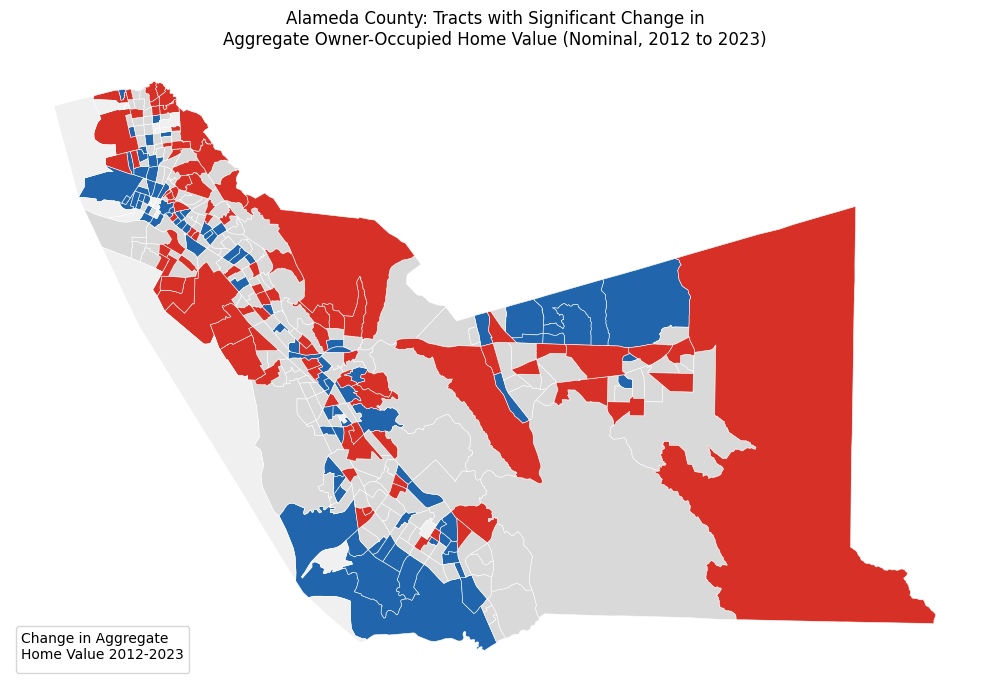

In [32]:
# Download the 2020 TIGER/Line census tract shapefile for California from the Census Bureau
tigerUrl = (
    "https://www2.census.gov/geo/tiger/TIGER2020/TRACT/"
    "tl_2020_06_tract.zip"
)

print("Downloading 2020 TIGER/Line tracts for California...")
tractsCA = gpd.read_file(tigerUrl)

# Filter to Alameda County and reproject to California Albers (meters)
tracts = tractsCA[tractsCA['COUNTYFP'] == '001'].copy()
tracts = tracts.to_crs(epsg=3310)
tracts['trtid20'] = tracts['GEOID']

# Join our results to the tract geometries
tractsMerged = tracts.merge(final, on='trtid20', how='left')

# Define significance thresholds: bottom 25% and top 25% of percent change
q25 = tractsMerged['pctChange'].quantile(0.25)
q75 = tractsMerged['pctChange'].quantile(0.75)

print(f"Bottom quartile threshold: {q25:.1f}%")
print(f"Top quartile threshold:    {q75:.1f}%")

# Label each tract
def label_change(pct):
    if pd.isna(pct):
        return 'No data'
    elif pct <= q25:
        return 'Large decrease (bottom 25%)'
    elif pct >= q75:
        return 'Large increase (top 25%)'
    else:
        return 'Moderate change'

tractsMerged['changeCategory'] = tractsMerged['pctChange'].apply(label_change)

# Map
colorMap = {
    'Large increase (top 25%)':    '#2166ac',  # blue
    'Moderate change':             '#d9d9d9',  # light grey
    'Large decrease (bottom 25%)': '#d73027',  # red
    'No data':                     '#f0f0f0',  # near-white
}

fig, ax = plt.subplots(figsize=(10, 10))

for category, color in colorMap.items():
    subset = tractsMerged[tractsMerged['changeCategory'] == category]
    subset.plot(ax=ax, color=color, edgecolor='white', linewidth=0.4, label=category)

ax.legend(title='Change in Aggregate\nHome Value 2012-2023', loc='lower left', fontsize=9)
ax.set_title(
    'Alameda County: Tracts with Significant Change in\nAggregate Owner-Occupied Home Value (Nominal, 2012 to 2023)',
    fontsize=12
)
ax.axis('off')
plt.tight_layout()
plt.show()